<img src="https://raw.githubusercontent.com/rbizoi/PythonFormation/main/images/e-brasil.png" width="850">

https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

# Les imports et initialisations des variables

In [27]:
from datetime import datetime
import pandas as pd, numpy as np, os, warnings, seaborn as sns, pickle, re, unicodedata
from datetime import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font1 = fm.FontProperties(size=20)
font2 = fm.FontProperties(size=24)

if int(str(sns.__version__).split('.')[1]) > 8 : 
    plt.style.use('seaborn-v0_8-darkgrid')
else:
    plt.style.use('seaborn-darkgrid')
    
sns.set(font_scale=2)
warnings.filterwarnings(action="ignore")

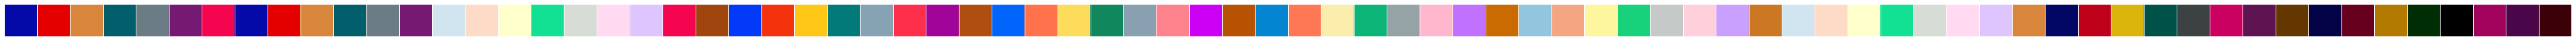

In [28]:
palette = [ "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973",
            "#f5054f", 
            "#030aa7", "#e50000", "#d8863b", "#005f6a", "#6b7c85", "#751973", "#d1e5f0", "#fddbc7",
            "#ffffcb", "#12e193", "#d8dcd6", "#ffdaf0", "#dfc5fe", "#f5054f", "#a0450e",
            "#0339f8", "#f4320c", "#fec615", "#017a79", "#85a3b2", "#fe2f4a", "#a00498", "#b04e0f",
            "#0165fc", "#ff724c", "#fddc5c", "#11875d", "#89a0b0", "#fe828c", "#cb00f5", "#b75203",
            "#0485d1", "#ff7855", "#fbeeac", "#0cb577", "#95a3a6", "#ffb7ce", "#c071fe", "#ca6b02",
            "#92c5de", "#f4a582", "#fef69e", "#18d17b", "#c5c9c7", "#ffcfdc", "#caa0ff", "#cb7723",
            "#d1e5f0", "#fddbc7", "#ffffcb", "#12e193", "#d8dcd6", "#ffdaf0", "#dfc5fe", "#d8863b",
            "#030764", "#be0119", "#dbb40c", "#005249", "#3c4142", "#cb0162", "#5d1451", "#653700",
            "#040348", "#67001f", "#b27a01", "#002d04", "#000000", "#a0025c", "#490648", "#3c0008"
          ]
# palette = ['#b2182b','#008827','#053061','#ffa500', '#34495e', '#e74c3c', 
#           '#9b59b6', '#0165fc','#2ecc71', '#cb7723', '#89a0b0']
sns.palplot(sns.color_palette(palette))

In [29]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [30]:
os.chdir("/dev/PythonFormation/donnees/ecommerce")

# Etoile 01

>> 99441
| #  | Column             | Non-Null Count | Dtype         |
|--- | ------             | -------------- | -----         |
| 0  | order_id           | 99441 non-null | object        |
| 1  | customer_id        | 99441 non-null | object        |
| 2  | purchase_timestamp | 99441 non-null | datetime64[ns]|
| 3  | approved_at        | 99281 non-null | datetime64[ns]|
| 4  | delivered_carrier  | 97658 non-null | datetime64[ns]|
| 5  | delivered_customer | 96476 non-null | datetime64[ns]|
| 6  | estimated_delivery | 99441 non-null | datetime64[ns]|
| 7  | status             | 99441 non-null | object        |
| 8  | annee              | 99441 non-null | int32         |
| 9  | mois               | 99441 non-null | int32         |
| 10 | annee_mois         | 99441 non-null | int32         |
| 11 | jour               | 99441 non-null | int32         |
| 12 | annee_jour         | 99441 non-null | int32         |
| 13 | jour_semaine       | 99441 non-null | int32         |
| 14 | trimestre          | 99441 non-null | int32         |
| 15 | annee_trimestre    | 99441 non-null | int32         |
| 16 | semaine            | 99441 non-null | int32         |
| 17 | annee_semaine      | 99441 non-null | int32         |
| 18 | heure              | 99441 non-null | int32         |
| 19 | approuvee          | 99281 non-null | float64       |
| 20 | envoyee            | 97658 non-null | float64       |
| 21 | livree             | 96476 non-null | float64       |
| 22 | estimee            | 99441 non-null | float64       |
| 23 | int_boleto         | 99440 non-null | float64       |
| 24 | int_credit_card    | 99440 non-null | float64       |
| 25 | int_debit_card     | 99440 non-null | float64       |
| 26 | int_not_defined    | 99440 non-null | float64       |
| 27 | int_voucher        | 99440 non-null | float64       |
| 28 | value_boleto       | 99440 non-null | float64       |
| 29 | value_credit_card  | 99440 non-null | float64       |
| 30 | value_debit_card   | 99440 non-null | float64       |
| 31 | value_not_defined  | 99440 non-null | float64       |
| 32 | value_voucher      | 99440 non-null | float64       |
| 33 | value              | 99440 non-null | float64       |
| 34 | answer_1           | 99441 non-null | int32         |
| 35 | answer_2           | 99441 non-null | int32         |
| 36 | answer_3           | 99441 non-null | int32         |
| 37 | answer_4           | 99441 non-null | int32         |
| 38 | answer_5           | 99441 non-null | int32         |
| 39 | comment_1          | 99441 non-null | int16         |
| 40 | comment_2          | 99441 non-null | int16         |
| 41 | comment_3          | 99441 non-null | int16         |
| 42 | comment_4          | 99441 non-null | int16         |
| 43 | comment_5          | 99441 non-null | int16         |
| 44 | creation_1         | 99441 non-null | int32         |
| 45 | creation_2         | 99441 non-null | int32         |
| 46 | creation_3         | 99441 non-null | int32         |
| 47 | creation_4         | 99441 non-null | int32         |
| 48 | creation_5         | 99441 non-null | int32         |
| 49 | score_1            | 99441 non-null | int64         |
| 50 | score_2            | 99441 non-null | int64         |
| 51 | score_3            | 99441 non-null | int64         |
| 52 | score_4            | 99441 non-null | int64         |
| 53 | score_5            | 99441 non-null | int64         |
| 54 | score              | 99441 non-null | int64         |
| 55 | answer             | 99441 non-null | int32         |
| 56 | creation           | 99441 non-null | int32         |
| 57 | comment            | 99441 non-null | int16         |
| 58 | customer_unique_id | 99441 non-null | object        |
| 59 | zip_code           | 99441 non-null | int32         |
| 60 | city               | 99441 non-null | object        |
| 61 | state              | 99441 non-null | object        |
| 62 | name_state         | 99441 non-null | object        |
| 63 | lat                | 99163 non-null | float64       |
| 64 | lng                | 99163 non-null | float64       |

In [31]:
donnees = pd.read_parquet('etoile03.parquet')

In [32]:
donnees.head()

,order_id,customer_id,purchase_timestamp,approved_at,delivered_carrier,delivered_customer,estimated_delivery,status,annee,mois,...,c_state,c_name_state,c_lat,c_lng,zip_code_y,s_city,s_state,s_name_state,s_lat,s_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,delivered,2017,10,...,SP,São Paulo,-23.576170,-46.587276,9350,maua,SP,São Paulo,-23.681180,-46.444127
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,delivered,2018,7,...,BA,Bahia,-12.126651,-45.008162,31570,belo horizonte,SP,São Paulo,-19.807013,-43.980966
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,delivered,2018,8,...,GO,Goiás,-16.744472,-48.514624,14840,guariba,SP,São Paulo,-21.364020,-48.228831
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,delivered,2017,11,...,RN,Rio Grande do Norte,-5.774611,-35.273916,31842,belo horizonte,MG,Minas Gerais,-19.836541,-43.921855
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,delivered,2018,2,...,SP,São Paulo,-23.675316,-46.515116,8752,mogi das cruzes,SP,São Paulo,-23.545033,-46.261847


In [33]:
donnees['value_item'] = donnees.value / donnees.groupby('order_id').order_item_id.transform('count')

In [34]:
donnees[['order_id','order_item_id','value','value_item']][donnees.order_item_id > 1].head()

,order_id,order_item_id,value,value_item
11,e6ce16cb79ec1d90b1da9085a6118aeb,2,259.06,129.530
28,acce194856392f074dbf9dada14d8d82,2,227.68,113.840
55,9faeb9b2746b9d7526aef5acb08e2aa0,2,151.04,75.520
61,66e4624ae69e7dc89bd50222b59f581f,2,91.68,45.840
69,688052146432ef8253587b930b01a06d,2,346.09,173.045


In [35]:
donnees['volume'] = donnees.length_cm * donnees.height_cm * donnees.width_cm

In [36]:
dCat = { nom:i for i, nom in enumerate(donnees.category_name.sort_values().unique())}

In [37]:
donnees['category'] = donnees.category_name.apply(lambda x : dCat[x])

In [38]:
donnees['respect_envois'] = donnees.livree - donnees.approuvee - donnees.limit

In [39]:
donnees['respect_envois'].describe()

count    110181.000000
mean          3.047693
std          15.408797
min         -47.963333
25%          -0.327778
50%           5.175278
75%          14.708889
max          23.996667
Name: respect_envois, dtype: float64

In [40]:
donnees.head()

,order_id,customer_id,purchase_timestamp,approved_at,delivered_carrier,delivered_customer,estimated_delivery,status,annee,mois,...,zip_code_y,s_city,s_state,s_name_state,s_lat,s_lng,value_item,volume,category,respect_envois
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,delivered,2017,10,...,9350,maua,SP,São Paulo,-23.681180,-46.444127,38.71,1976.0,49,10.121111
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,delivered,2018,7,...,31570,belo horizonte,SP,São Paulo,-19.807013,-43.980966,141.46,4693.0,62,5.341111
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,delivered,2018,8,...,14840,guariba,SP,São Paulo,-21.364020,-48.228831,179.12,9576.0,5,8.908889
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,delivered,2017,11,...,31842,belo horizonte,MG,Minas Gerais,-19.836541,-43.921855,72.20,6000.0,63,4.413889
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,delivered,2018,2,...,8752,mogi das cruzes,SP,São Paulo,-23.545033,-46.261847,28.62,11475.0,69,-3.273611


In [41]:
travail = donnees[['order_id','order_item_id', 'product_id', 'customer_id', 'seller_id',  'customer_unique_id', 'value_item', 'price', 'freight_value','weight_g','volume']] #,'c_lat', 'c_lng', 's_lat', 's_lng'

In [42]:
travail.set_index(['order_id','order_item_id', 'product_id', 'customer_id', 'seller_id',  'customer_unique_id'],inplace=True)

In [43]:
travail.isna().sum()

value_item        3
price             0
freight_value     0
weight_g         18
volume           18
dtype: int64

In [44]:
travail.dropna(inplace=True)

## <b><div style='padding:15px;background-color:#d8dcd6;color:#030aa7;font-size:120%;text-align: left'>Centrage et réduction des données</div></b>
<table>
<tr>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/moyenne.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/ecart_type.png"></th>
<th><img src="https://raw.githubusercontent.com/rbizoi/MachineLearning/refs/heads/master/images/centrage_reduction.png"></th>
</tr>
</table>

In [45]:
from sklearn.preprocessing import StandardScaler
modelStd = StandardScaler()
modelStd.fit(travail)

travail[travail.columns] = modelStd.transform(travail)
travail.head()

,,,,,,value_item,price,freight_value,weight_g,volume
order_id,order_item_id,product_id,customer_id,seller_id,customer_unique_id,,,,,
e481f51cbdc54678b7cc49136f2d6af7,1,87285b34884572647811a353c7ac498a,9ef432eb6251297304e76186b10a928d,3504c0cb71d7fa48d967e0e4c94d59d9,7c396fd4830fd04220f754e42b4e5bff,-0.536360,-0.493895,-0.713056,-0.424803,-0.566557
53cdb2fc8bc7dce0b6741e2150273451,1,595fac2a385ac33a80bd5114aec74eb8,b0830fb4747a6c6d20dea0b8c802d7ef,289cdb325fb7e7f891c38608bf9e0962,af07308b275d755c9edb36a90c618231,0.004157,-0.010638,0.175138,-0.451458,-0.450538
47770eb9100c2d0c44946d9cf07ec65d,1,aa4383b373c6aca5d8797843e5594415,41ce2a54c0b03bf3443c3d931a367089,4869f7a5dfa277a7dca6462dcf3b52b2,3a653a41f6f9fc3d2a113cf8398680e8,0.202267,0.213803,-0.048808,-0.446127,-0.242029
949d5b44dbf5de918fe9c16f97b45f8a,1,d0b61bfb1de832b15ba9d266ca96e5b0,f88197465ea7920adcdbec7375364d82,66922902710d126a0e7d26b0e3805106,7c142cf63193a1473d2e66489a9ae977,-0.360186,-0.412126,0.456020,-0.438130,-0.394728
ad21c59c0840e6cb83a9ceb5573f8159,1,65266b2da20d04dbe00c5c2d3bb7859e,8ab97904e6daea8866dbdbc4fb7aad2c,2c9e548be18521d1c43cde1c582c6de8,72632f0f9dd73dfee390c9b22eb56dd6,-0.589439,-0.548861,-0.713056,-0.491441,-0.160940


In [46]:
modelPCA = PCA(svd_solver='full')
modelPCA.fit(travail)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'full'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [47]:
modelPCA.explained_variance_ratio_.cumsum()*100

array([ 61.91032447,  87.23513021,  96.00889267,  99.93685774,
       100.        ])

In [48]:
modelPCA.n_components_

5

In [49]:
inertie = pd.DataFrame(modelPCA.explained_variance_ratio_,columns=['Inertie']) 
inertie['Label'] = np.round(modelPCA.explained_variance_ratio_.cumsum()*100,2)
inertie['Dimension'] = range(1,len(modelPCA.explained_variance_)+1)
inertie['Inertie'] = np.round(inertie['Inertie']*100,2)
dim = modelPCA.n_components_
inertie = inertie[inertie['Dimension']<= dim]

In [50]:
sum(modelPCA.explained_variance_ratio_.cumsum()*100 <= 95) + 1

np.int64(3)

In [51]:
inertie[inertie.Dimension <= sum(modelPCA.explained_variance_ratio_.cumsum()*100 <= 95) + 1]

,Inertie,Label,Dimension
0,61.91,61.91,1
1,25.32,87.24,2
2,8.77,96.01,3


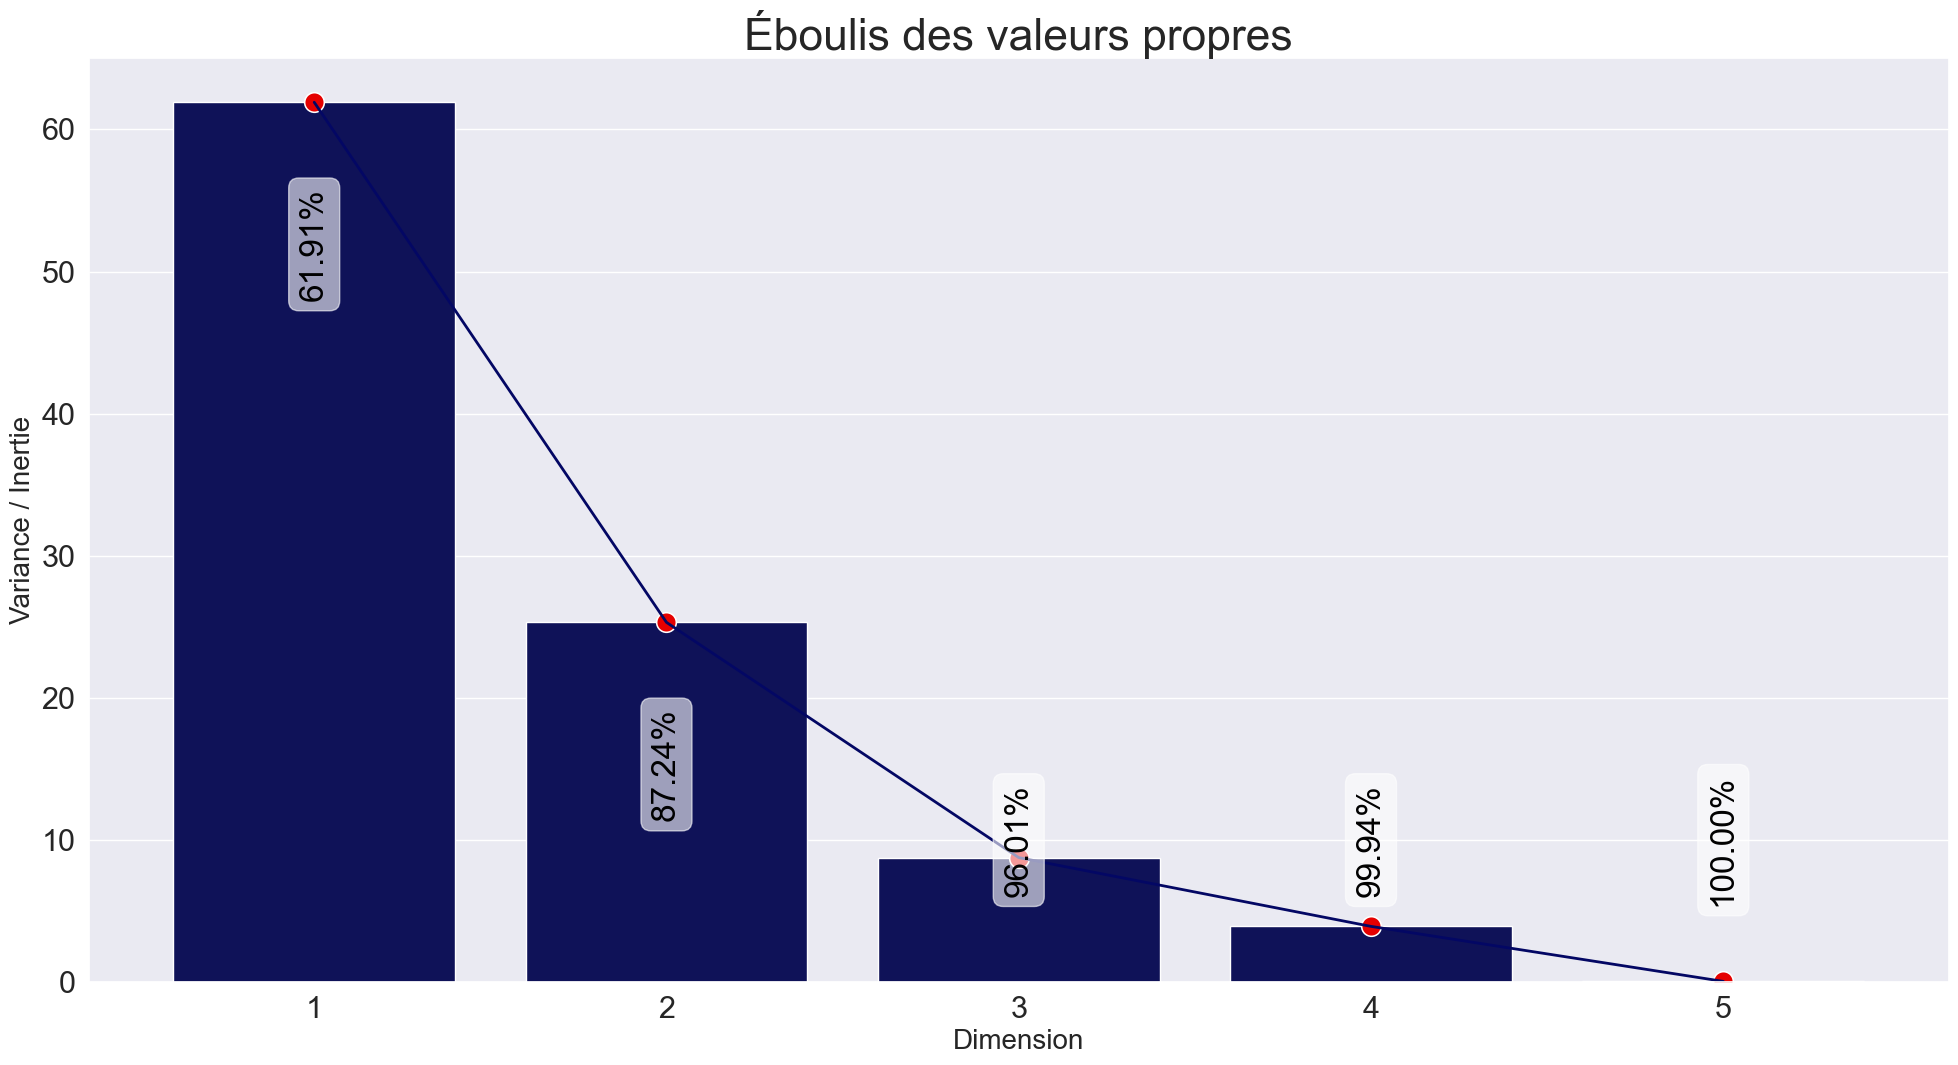

In [52]:
fig, ax = plt.subplots(figsize=(24,12));
graph = sns.barplot(x="Dimension",y='Inertie', data=inertie[inertie.Dimension <= 10], color="#030764", ax=ax)

for i,(nom,valeur) in enumerate(zip(inertie[inertie.Dimension <= 10].sort_values('Dimension').Label,inertie.sort_values('Dimension').Inertie)):
    # valeur = 0.1 if valeur - 0.1 < 0.1 else valeur - 0.1
    valeur = 10 if valeur - 10 < 10 else valeur - 10
    delta =  i 
    graph.text(
                delta ,
                valeur,
                f'{nom:0.2f}%',
                color='black',
                rotation='vertical',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6),
                verticalalignment='center',
                horizontalalignment='center',
               )
    
graph = sns.lineplot( x=inertie[inertie.Dimension <= 10].Dimension - 1,
                      y='Inertie',
                      data=inertie,
                      estimator = None, 
                      lw        = 2, 
                      ci        = None,
                      color     = "#030764",
                      ax    = ax);

sns.scatterplot(x=inertie[inertie.Dimension <= 10].Dimension - 1,
                y     = 'Inertie',
                data  = inertie,
                s     = 200,
                # ci    = None, 
                color = "#e50000",
                ax    = ax);    
    
ax.set_xlabel('Dimension', fontproperties=font1)
ax.set_ylabel('Variance / Inertie', fontproperties=font1)
ax.set_title('Éboulis des valeurs propres', fontproperties=fm.FontProperties(size=32))

# sauvegarderImage('Choix du nombre des dimensions01--Temperatures')
sns.set(font_scale=2)

In [54]:
n_components = 3
modelPCA = PCA(n_components=n_components).set_output(transform="pandas")
donneesACP = modelPCA.fit_transform(travail)
donneesACP.columns = [f'Dimension{i:02d}' for i in range(1,n_components+1)]
donneesACP.index = travail.index

In [55]:
donneesACP.head()

,,,,,,Dimension01,Dimension02,Dimension03
order_id,order_item_id,product_id,customer_id,seller_id,customer_unique_id,,,
e481f51cbdc54678b7cc49136f2d6af7,1,87285b34884572647811a353c7ac498a,9ef432eb6251297304e76186b10a928d,3504c0cb71d7fa48d967e0e4c94d59d9,7c396fd4830fd04220f754e42b4e5bff,-1.222006,0.037213,-0.180438
53cdb2fc8bc7dce0b6741e2150273451,1,595fac2a385ac33a80bd5114aec74eb8,b0830fb4747a6c6d20dea0b8c802d7ef,289cdb325fb7e7f891c38608bf9e0962,af07308b275d755c9edb36a90c618231,-0.323787,0.359377,0.450735
47770eb9100c2d0c44946d9cf07ec65d,1,aa4383b373c6aca5d8797843e5594415,41ce2a54c0b03bf3443c3d931a367089,4869f7a5dfa277a7dca6462dcf3b52b2,3a653a41f6f9fc3d2a113cf8398680e8,-0.139928,0.532104,0.134272
949d5b44dbf5de918fe9c16f97b45f8a,1,d0b61bfb1de832b15ba9d266ca96e5b0,f88197465ea7920adcdbec7375364d82,66922902710d126a0e7d26b0e3805106,7c142cf63193a1473d2e66489a9ae977,-0.514110,-0.137314,0.754949
ad21c59c0840e6cb83a9ceb5573f8159,1,65266b2da20d04dbe00c5c2d3bb7859e,8ab97904e6daea8866dbdbc4fb7aad2c,2c9e548be18521d1c43cde1c582c6de8,72632f0f9dd73dfee390c9b22eb56dd6,-1.124647,-0.178587,-0.291692


In [56]:
import scipy.cluster.hierarchy as sch

def afficheDendrogram(*args, **kwargs):
    max_d = kwargs.pop('max_d', None)
    if max_d and 'color_threshold' not in kwargs:
        kwargs['color_threshold'] = max_d
    annotate_above = kwargs.pop('annotate_above', 0)

    ddata = sch.dendrogram(*args, **kwargs)

    if not kwargs.get('no_plot', False):
        plt.title('Hierarchical Clustering Dendrogram (truncated)')
        plt.xlabel('sample index or (cluster size)')
        plt.ylabel('distance')
        for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
            x = 0.5 * sum(i[1:3])
            y = d[1]
            if y > annotate_above:
                plt.plot(x, y, 'o', c=c)
                plt.annotate("%.3g" % y, (x, y), xytext=(0, -5),
                             textcoords='offset points',
                             va='top', ha='center')
        if max_d:
            plt.axhline(y=max_d, c='k')
    return ddata

In [ ]:
Z = sch.linkage(donneesACP.values, method = 'ward')

In [ ]:
plt.figure(figsize=(56, 10))
afficheDendrogram(
    Z,
    # truncate_mode='lastp',
    #p=12,
    leaf_rotation=90.,
    leaf_font_size=24.,
    show_contracted=True,
    annotate_above=60,  # useful in small plots so annotations don't overlap
    # max_d=15,  # plot a horizontal cut-off line
   # labels = labels.values
)
plt.show()